# Projeto Final — Introdução à Ciência de Dados

# Desaparecimento de Pessoas no DF — Análise por Idade e Sexo (2017–2021)
**Disciplina:** Introdução à Ciência de Dados  
**Integrantes:** Davi Reis Borges · Gustavo Lisboa Gonçalves · Rafael Guimarães Souza · Marcos do Nascimento Alvarez  
**Fonte dos dados:** [Portal de Dados Abertos do DF — SSPDF/COOAFESP](https://www.dados.df.gov.br/dataset#/por-regiao-administrativa)

---
**Pergunta principal:**  
> *Como o perfil de pessoas desaparecidas no Distrito Federal evoluiu entre 2017 e 2021, considerando faixa etária e sexo — e quais grupos apresentam padrões mais persistentes ou mais sujeitos a variações ao longo do período?*

## 1. Pergunta orientadora

**Pergunta principal:** Como o perfil de pessoas desaparecidas no Distrito Federal evoluiu entre 2017 e 2021, considerando faixa etária e sexo — e quais grupos apresentam padrões mais persistentes ou mais sujeitos a variações ao longo do período?

**Perguntas secundárias:**

1. A faixa de 12 a 17 anos, que concentra a maior proporção de desaparecimentos femininos, manteve essa disparidade de sexo de forma consistente ao longo dos cinco anos, ou houve alguma inflexão?
2. O total geral de desaparecimentos caiu entre 2017 e 2020 e subiu levemente em 2021. Essa variação está distribuída igualmente entre todas as faixas etárias ou é concentrada em algum grupo específico?
3. A proporção de homens desaparecidos cresceu de 2017 para 2021. Em quais faixas etárias esse crescimento é mais expressivo?


In [ ]:
# Bibliotecas utilizadas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib import patheffects
from matplotlib.lines import Line2D

# Estilo visual profissional
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (12, 6.5),
    "figure.dpi": 140,
    "figure.facecolor": "#F7F7F7",
    "axes.facecolor": "#F7F7F7",
    "axes.edgecolor": "#CCCCCC",
    "axes.linewidth": 0.6,
    "axes.titlesize": 17,
    "axes.titleweight": "bold",
    "axes.titlepad": 24,
    "axes.labelsize": 11.5,
    "axes.labelpad": 10,
    "axes.labelcolor": "#444444",
    "grid.color": "#E8E8E8",
    "grid.linewidth": 0.5,
    "grid.alpha": 0.8,
    "legend.fontsize": 10,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "#DDDDDD",
    "legend.shadow": False,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "font.family": "sans-serif",
    "text.color": "#333333",
})

PALETTE_FAIXAS = ["#4E79A7", "#F28E2B", "#E15759", "#76B7B2", "#59A14F", "#B07AA1"]
PALETTE_SEXO = {"masc": "#4E79A7", "fem": "#E15759"}

def fonte_rodape(ax, y=-0.14):
    ax.text(0, y, "Fonte: SSPDF — Banco Millenium/COOAFESP | Portal de Dados Abertos do DF",
            transform=ax.transAxes, fontsize=8, color="#999999", style="italic")

def subtitulo(ax, texto, y=1.02):
    ax.text(0.5, y, texto, transform=ax.transAxes, fontsize=10.5,
            color="#777777", ha="center", va="bottom")

def limpar_spines(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.4)
    ax.spines["left"].set_color("#BBBBBB")
    ax.spines["bottom"].set_linewidth(0.4)
    ax.spines["bottom"].set_color("#BBBBBB")
    ax.tick_params(axis="both", length=3, width=0.4, colors="#888888")


## 2. Carregamento do conjunto de dados

O arquivo original (`/content/desaparecimento-de-pessoasidade-e-sexojandez-20172021.csv `) não é uma tabela única e tidy: ele contém **5 tabelas anuais empilhadas** (2017 a 2021), cada uma com cabeçalho próprio, linha de "Fonte" e linhas em branco entre elas. Por isso, antes de usar o `pandas` normalmente, escrevemos uma função de parsing que percorre o arquivo bruto, identifica cada bloco anual e monta um único DataFrame "tidy" (uma linha por combinação ano × faixa etária).

In [ ]:
CSV_FILENAME = "/content/desaparecimento-de-pessoasidade-e-sexojandez-20172021.csv"

In [ ]:
# Função de parsing: o CSV bruto traz 5 tabelas anuais empilhadas.
# Convertemos para um único DataFrame "tidy": uma linha por (ano, faixa etária).

import csv

def parse_desaparecidos_csv(path):
    with open(path, encoding="latin1") as f:
        linhas = list(csv.reader(f, delimiter=";"))

    registros = []
    ano_atual = None

    for linha in linhas:
        celulas = [c.strip() for c in linha]

        # Identifica o cabeçalho de cada bloco anual, ex: "DESAPARECIDOS POR IDADE E SEXO - Jan/dez de 2017."
        if celulas and celulas[0].upper().startswith("DESAPARECIDOS POR IDADE E SEXO"):
            for token in celulas[0].split():
                token_limpo = token.strip(".")
                if token_limpo.isdigit() and len(token_limpo) == 4:
                    ano_atual = int(token_limpo)
            continue

        if ano_atual is None:
            continue

        faixa = celulas[0].upper() if celulas else ""
        faixas_validas = [
            "ATÉ 11 ANOS", "DE 12 A 17 ANOS", "DE 18 A 30 ANOS",
            "DE 31 A 50 ANOS", "MAIS DE 50 ANOS", "NÃO INFORMADO", "TOTAL",
        ]
        if faixa not in faixas_validas:
            continue

        def to_int(x):
            x = x.replace("%", "").strip()
            return int(x) if x.isdigit() else np.nan

        def to_pct(x):
            x = x.replace("%", "").strip()
            return float(x) / 100 if x.replace(".", "", 1).isdigit() else np.nan

        try:
            total = to_int(celulas[1])
            pct_participacao = to_pct(celulas[2])
            masc = to_int(celulas[3])
            pct_masc = to_pct(celulas[4])
            fem = to_int(celulas[5])
            pct_fem = to_pct(celulas[6])
        except IndexError:
            continue

        registros.append({
            "ano": ano_atual,
            "faixa_etaria": faixa.title().replace("Não Informado", "Não informado"),
            "total": total,
            "participacao_pct": pct_participacao,
            "masculino": masc,
            "masculino_pct": pct_masc,
            "feminino": fem,
            "feminino_pct": pct_fem,
        })

    return pd.DataFrame(registros)


df_bruto = parse_desaparecidos_csv(CSV_FILENAME)
df_bruto.head(10)


,ano,faixa_etaria,total,participacao_pct,masculino,masculino_pct,feminino,feminino_pct
0,2017,Até 11 Anos,137,0.05,82,0.60,55,0.40
1,2017,De 12 A 17 Anos,1073,0.39,338,0.32,735,0.68
2,2017,De 18 A 30 Anos,670,0.24,439,0.66,231,0.34
3,2017,De 31 A 50 Anos,611,0.22,474,0.78,137,0.22
4,2017,Mais De 50 Anos,244,0.09,180,0.74,64,0.26
5,2017,Não informado,32,0.01,25,0.78,7,0.22
6,2017,Total,2767,1.00,1538,0.56,1229,0.44
7,2018,Até 11 Anos,85,0.03,54,0.64,31,0.36
8,2018,De 12 A 17 Anos,905,0.36,306,0.34,599,0.66
9,2018,De 18 A 30 Anos,594,0.24,391,0.66,203,0.34


## 3. Entendimento e descrição do conjunto de dados

**O que representa cada coluna:**

- `ano`: ano de referência da tabela (2017 a 2021) — variável temporal.
- `faixa_etaria`: faixa etária da pessoa desaparecida — variável categórica (7 categorias, incluindo a linha "Total").
- `total`: número absoluto de pessoas desaparecidas naquela faixa etária e ano — variável numérica (contagem).
- `participacao_pct`: participação percentual daquela faixa etária no total do ano — variável numérica (proporção).
- `masculino` / `feminino`: número absoluto de desaparecidos do sexo masculino/feminino na faixa — variável numérica (contagem).
- `masculino_pct` / `feminino_pct`: percentual de homens/mulheres dentro daquela faixa etária — variável numérica (proporção).

A linha `faixa_etaria == "Total"` é, na verdade, um **subtotal** (soma das demais faixas em cada ano), não uma faixa etária real — ela será tratada separadamente na etapa de limpeza.


In [ ]:
# Tamanho do conjunto de dados
print(f"Linhas: {df_bruto.shape[0]}  |  Colunas: {df_bruto.shape[1]}")
df_bruto.dtypes


Linhas: 35  |  Colunas: 8


,0
ano,int64
faixa_etaria,object
total,int64
participacao_pct,float64
masculino,int64
masculino_pct,float64
feminino,int64
feminino_pct,float64


In [ ]:
# Estatísticas básicas das colunas numéricas
df_bruto.describe()


,ano,total,participacao_pct,masculino,masculino_pct,feminino,feminino_pct
count,35.00000,35.000000,35.000000,35.000000,35.000000,35.000000,35.000000
mean,2019.00000,710.514286,0.284857,418.057143,0.615143,292.457143,0.384857
std,1.43486,805.015066,0.318132,469.881584,0.139819,359.042218,0.139819
min,2017.00000,28.000000,0.010000,17.000000,0.310000,7.000000,0.200000
25%,2018.00000,125.000000,0.045000,73.500000,0.570000,51.500000,0.270000
50%,2019.00000,553.000000,0.240000,284.000000,0.640000,170.000000,0.360000
75%,2020.00000,803.500000,0.310000,485.000000,0.730000,315.500000,0.430000
max,2021.00000,2971.000000,1.000000,1710.000000,0.800000,1261.000000,0.690000


## 4. Avaliação de completude e limpeza dos dados

### 4.1 Completude (valores faltantes)


In [ ]:
nulos = df_bruto.isna().sum()
prop_nulos = (df_bruto.isna().mean() * 100).round(2)
pd.DataFrame({"qtd_nulos": nulos, "%_nulos": prop_nulos})


,qtd_nulos,%_nulos
ano,0,0.0
faixa_etaria,0,0.0
total,0,0.0
participacao_pct,0,0.0
masculino,0,0.0
masculino_pct,0,0.0
feminino,0,0.0
feminino_pct,0,0.0


O conjunto, após o parsing, não apresenta valores nulos: o dado bruto da SSPDF já vinha completo para as 7 categorias x 5 anos x 7 colunas (sem campos vazios). O risco de "falta de dado" aqui é estrutural (categoria "Não informado" representando ~1% dos casos por ano), não um problema de qualidade do arquivo.

### 4.2 Limpeza realizada

1. **Separação do subtotal "Total"**: a linha "Total" de cada ano foi removida do DataFrame de faixas etárias (`df`) e guardada em um DataFrame separado (`df_totais`), pois ela é uma soma e não uma categoria, e mantê-la junto distorceria contagens e gráficos (duplicaria os casos).
2. **Tipagem**: no arquivo bruto, valores numéricos e percentuais vêm como texto (ex.: `"56%"`, `"2767"`). A função de parsing já converte `total`/`masculino`/`feminino` para `int` e os percentuais para `float` na escala 0–1, evitando erros de cálculo.
3. **Padronização de texto**: nomes de faixa etária vieram em CAIXA ALTA no CSV original (`"DE 12 A 17 ANOS"`); padronizamos para Title Case (`"De 12 A 17 Anos"`) para facilitar leitura nos gráficos.
4. **Checagem de consistência**: validamos que `masculino + feminino == total` e que a soma dos `total` por faixa etária (exceto "Total") é igual ao valor da linha "Total" de cada ano — ambas as checagens fecharam, confirmando a integridade do parsing.


In [ ]:
# Separação do subtotal "Total" e checagens de consistência
df_totais = df_bruto[df_bruto["faixa_etaria"] == "Total"].drop(columns=["faixa_etaria"]).reset_index(drop=True)
df = df_bruto[df_bruto["faixa_etaria"] != "Total"].reset_index(drop=True)

# Checagem 1: masculino + feminino == total, em cada linha
checagem_soma_sexo = (df["masculino"] + df["feminino"] == df["total"]).all()

# Checagem 2: soma das faixas por ano == linha "Total" daquele ano
soma_por_ano = df.groupby("ano")["total"].sum()
total_oficial_por_ano = df_totais.set_index("ano")["total"]
checagem_soma_ano = (soma_por_ano == total_oficial_por_ano).all()

print("Masculino + Feminino == Total em todas as linhas?", checagem_soma_sexo)
print("Soma das faixas por ano == linha Total do ano?   ", checagem_soma_ano)

df.head(10)


Masculino + Feminino == Total em todas as linhas? True
Soma das faixas por ano == linha Total do ano?    True


,ano,faixa_etaria,total,participacao_pct,masculino,masculino_pct,feminino,feminino_pct
0,2017,Até 11 Anos,137,0.05,82,0.60,55,0.40
1,2017,De 12 A 17 Anos,1073,0.39,338,0.32,735,0.68
2,2017,De 18 A 30 Anos,670,0.24,439,0.66,231,0.34
3,2017,De 31 A 50 Anos,611,0.22,474,0.78,137,0.22
4,2017,Mais De 50 Anos,244,0.09,180,0.74,64,0.26
5,2017,Não informado,32,0.01,25,0.78,7,0.22
6,2018,Até 11 Anos,85,0.03,54,0.64,31,0.36
7,2018,De 12 A 17 Anos,905,0.36,306,0.34,599,0.66
8,2018,De 18 A 30 Anos,594,0.24,391,0.66,203,0.34
9,2018,De 31 A 50 Anos,655,0.26,483,0.74,172,0.26


### 4.3 Tipagem final

Após o parsing, as colunas ficaram com os tipos corretos para análise:

- `ano`: inteiro (variável temporal/discreta)
- `faixa_etaria`: categórica (texto)
- `total`, `masculino`, `feminino`: inteiros (contagens)
- `participacao_pct`, `masculino_pct`, `feminino_pct`: float na escala 0–1 (proporções)

Não foi necessário nenhum recast adicional além do que já é feito dentro de `parse_desaparecidos_csv`.


## 5. Análise e visualização

A seguir, seis gráficos construídos com `matplotlib`/`seaborn`, cada um seguido da interpretação correspondente.

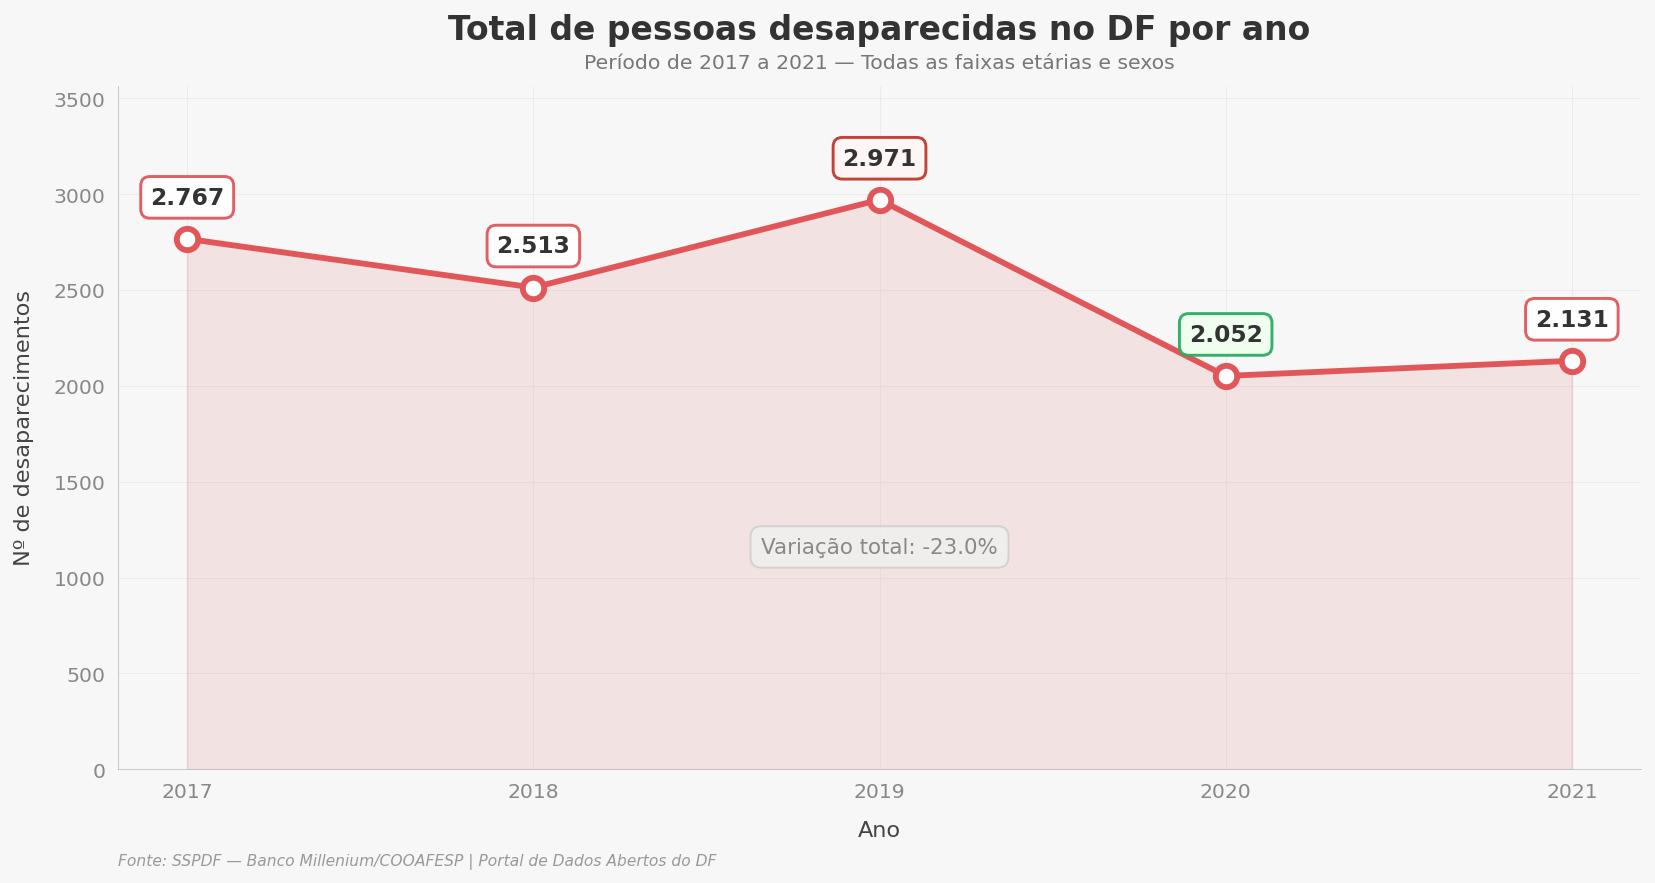

In [ ]:
# Gráfico 1 - Evolução do total de desaparecimentos por ano
fig, ax = plt.subplots(figsize=(12, 6.5))

anos = df_totais["ano"].values
totais = df_totais["total"].values

ax.fill_between(anos, totais, alpha=0.08, color="#E15759", zorder=1)
ax.fill_between(anos, totais, alpha=0.05, color="#E15759", zorder=1)

for i in range(len(anos) - 1):
    ax.plot(anos[i:i+2], totais[i:i+2], color="#E15759", linewidth=3, solid_capstyle="round", zorder=3)

ax.plot(anos, totais, marker="o", color="#E15759", linewidth=0, markersize=11,
        markerfacecolor="white", markeredgewidth=3, markeredgecolor="#E15759", zorder=5)

pico = totais.max()
vale = totais.min()
for x, y in zip(anos, totais):
    cor_borda = "#C0392B" if y == pico else ("#27AE60" if y == vale else "#E15759")
    cor_fundo = "#FFF5F5" if y == pico else ("#F0FFF0" if y == vale else "white")
    ax.annotate(f"{int(y):,}".replace(",", "."), (x, y),
                textcoords="offset points", xytext=(0, 18), ha="center",
                fontsize=12, fontweight="bold", color="#333333",
                bbox=dict(boxstyle="round,pad=0.4", facecolor=cor_fundo,
                          edgecolor=cor_borda, linewidth=1.5, alpha=0.95))

variacao = ((totais[-1] - totais[0]) / totais[0]) * 100
ax.annotate(f"Variação total: {variacao:+.1f}%", xy=(2019, min(totais) * 0.55),
            fontsize=11, color="#888888", ha="center",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#F0F0F0", edgecolor="#CCCCCC", alpha=0.8))

ax.set_title("Total de pessoas desaparecidas no DF por ano")
subtitulo(ax, "Período de 2017 a 2021 — Todas as faixas etárias e sexos")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de desaparecimentos")
ax.set_xticks(anos)
ax.set_ylim(bottom=0, top=max(totais) * 1.2)
limpar_spines(ax)
fonte_rodape(ax)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


**Interpretação:** o total de desaparecimentos caiu de forma constante entre 2017 (2.767) e 2020 (2.052), uma queda de aproximadamente 26%, e teve uma leve recuperação em 2021 (2.131). Essa trajetória de queda coincide com o período de maior restrição de mobilidade da pandemia de COVID-19, o que é uma hipótese plausível para a redução — embora o conjunto de dados, por si só, não permita confirmar a causa.

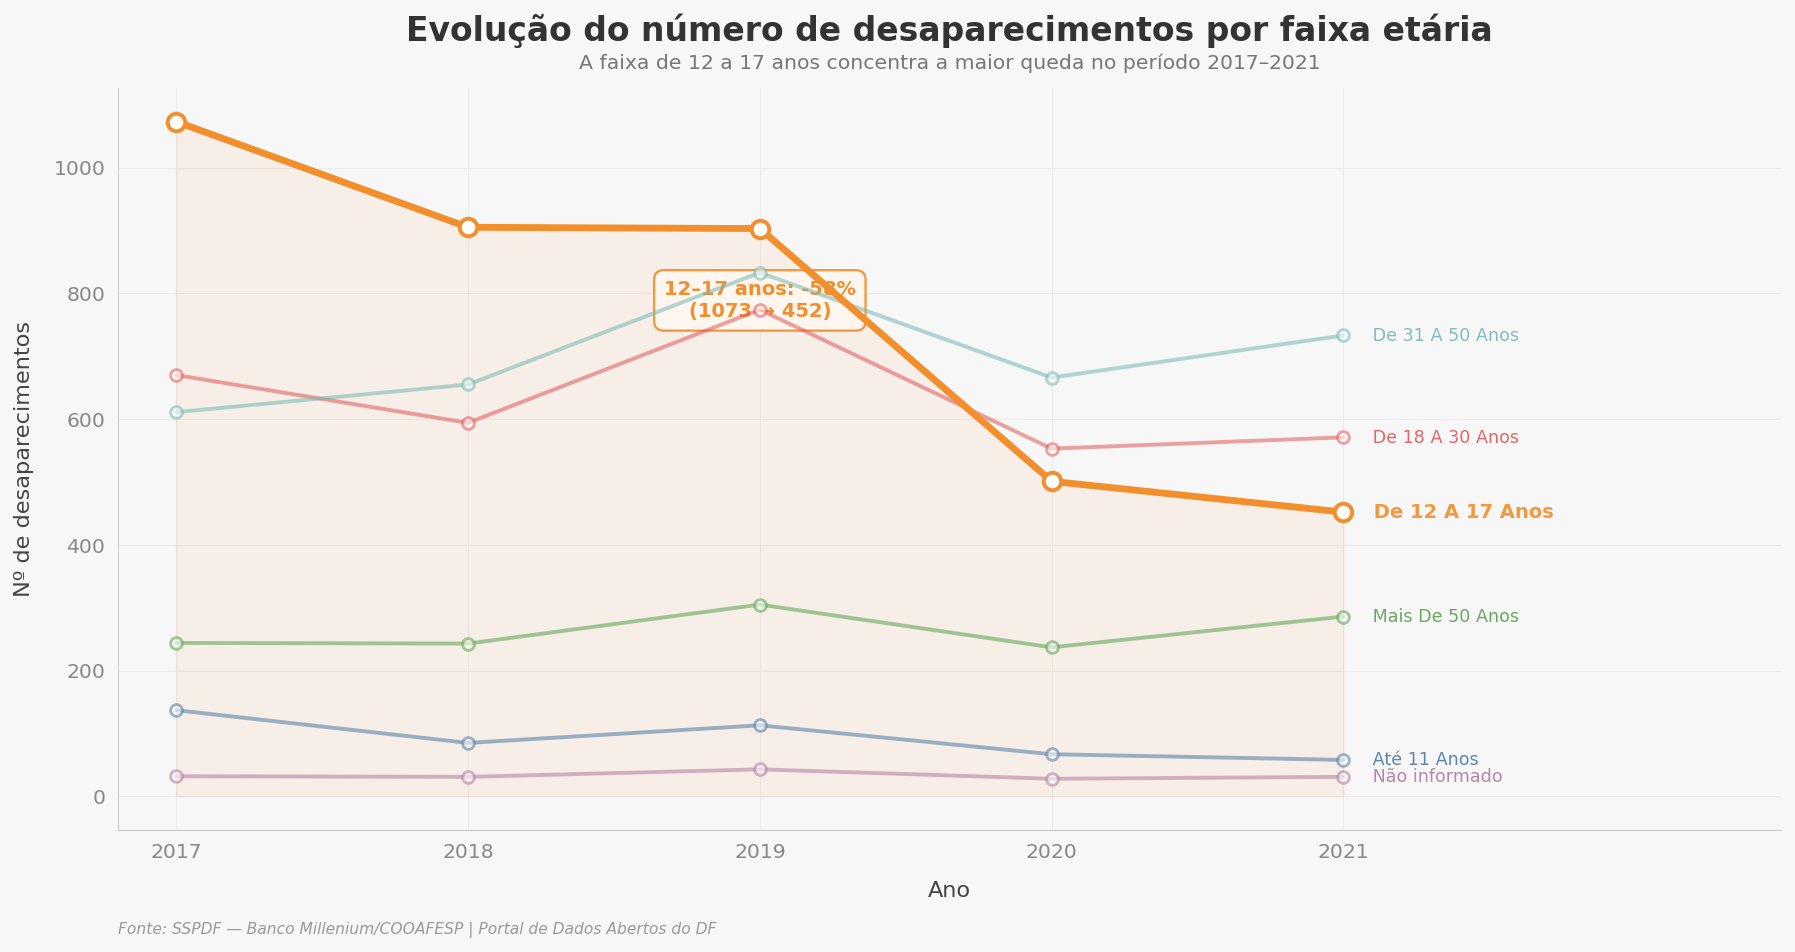

In [ ]:
# Gráfico 2 - Evolução do total de desaparecimentos por faixa etária ao longo dos anos
fig, ax = plt.subplots(figsize=(13, 7))

faixas_ordenadas = sorted(df["faixa_etaria"].unique())
destaque = "De 12 A 17 Anos"

for i, faixa in enumerate(faixas_ordenadas):
    grupo = df[df["faixa_etaria"] == faixa].sort_values("ano")
    cor = PALETTE_FAIXAS[i % len(PALETTE_FAIXAS)]
    eh_destaque = faixa == destaque
    lw = 3.5 if eh_destaque else 2
    alpha_linha = 1.0 if eh_destaque else 0.55
    ms = 9 if eh_destaque else 6

    if eh_destaque:
        ax.fill_between(grupo["ano"], grupo["total"], alpha=0.08, color=cor)

    ax.plot(grupo["ano"], grupo["total"], marker="o", label=faixa,
            linewidth=lw, markersize=ms, color=cor, alpha=alpha_linha,
            markerfacecolor="white", markeredgewidth=2 if eh_destaque else 1.5,
            markeredgecolor=cor, zorder=6 if eh_destaque else 4)

    ultimo = grupo.iloc[-1]
    peso = "bold" if eh_destaque else "normal"
    tam = 10 if eh_destaque else 9
    ax.text(ultimo["ano"] + 0.08, ultimo["total"], f" {faixa}",
            fontsize=tam, fontweight=peso, color=cor, va="center", alpha=0.9)

dados_destaque = df[df["faixa_etaria"] == destaque].sort_values("ano")
v0, v1 = dados_destaque.iloc[0]["total"], dados_destaque.iloc[-1]["total"]
var = ((v1 - v0) / v0) * 100
ax.annotate(f"12–17 anos: {var:+.0f}%\n({int(v0)} → {int(v1)})",
            xy=(2019, (v0 + v1) / 2), fontsize=10, color=PALETTE_FAIXAS[1],
            ha="center", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.5", facecolor="#FFF8F0",
                      edgecolor=PALETTE_FAIXAS[1], alpha=0.9, linewidth=1.2))

ax.set_title("Evolução do número de desaparecimentos por faixa etária")
subtitulo(ax, "A faixa de 12 a 17 anos concentra a maior queda no período 2017–2021")
ax.set_xlabel("Ano")
ax.set_ylabel("Nº de desaparecimentos")
ax.set_xticks(sorted(df["ano"].unique()))
ax.set_xlim(2016.8, 2022.5)
limpar_spines(ax)
fonte_rodape(ax)

plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


**Interpretação:** a faixa "De 12 a 17 Anos" é a que mais contribui para a queda geral — caiu de 1.073 casos em 2017 para 452 em 2021 (-58%). Já a faixa "De 31 a 50 Anos" se manteve relativamente estável e até cresceu (611 em 2017 para 733 em 2021), assim como "Mais de 50 Anos". Isso responde à segunda pergunta secundária: **a queda do total não é distribuída igualmente — ela está concentrada quase inteiramente na faixa de 12 a 17 anos**, enquanto faixas adultas têm trajetória estável ou de leve crescimento.

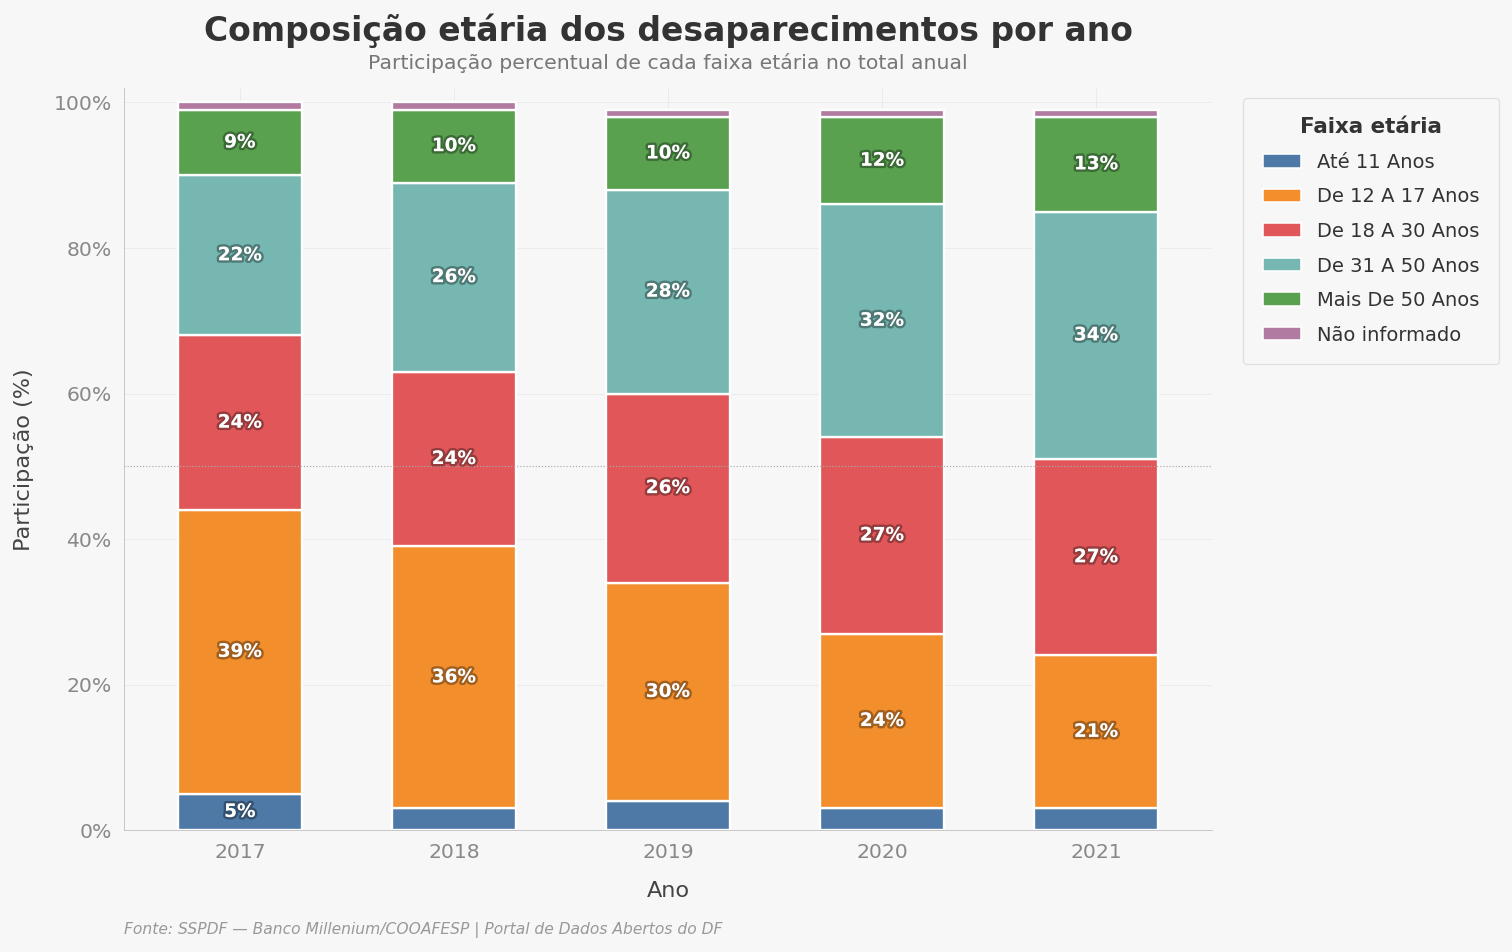

In [ ]:
# Gráfico 3 - Participação percentual de cada faixa etária no total de cada ano (barras empilhadas)
pivot_part = df.pivot(index="ano", columns="faixa_etaria", values="participacao_pct").sort_index()
ordem_faixas = ["Até 11 Anos", "De 12 A 17 Anos", "De 18 A 30 Anos", "De 31 A 50 Anos", "Mais De 50 Anos", "Não informado"]
pivot_part = pivot_part[[c for c in ordem_faixas if c in pivot_part.columns]]

fig, ax = plt.subplots(figsize=(11, 7))
pivot_part.plot(kind="bar", stacked=True, ax=ax, color=PALETTE_FAIXAS[:len(pivot_part.columns)],
                edgecolor="white", linewidth=1.2, width=0.58)

for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0.045:
            pct_texto = f"{height:.0%}"
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2,
                    pct_texto, ha="center", va="center",
                    fontsize=9.5, fontweight="bold", color="white",
                    path_effects=[patheffects.withStroke(linewidth=2.5, foreground="#00000055")])

ax.axhline(y=0.5, color="#AAAAAA", linewidth=0.6, linestyle=":", zorder=1)

ax.set_title("Composição etária dos desaparecimentos por ano")
subtitulo(ax, "Participação percentual de cada faixa etária no total anual")
ax.set_xlabel("Ano")
ax.set_ylabel("Participação (%)")
ax.set_xticklabels(pivot_part.index, rotation=0)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 1.02)
limpar_spines(ax)

handles = [mpatches.Patch(facecolor=PALETTE_FAIXAS[i], edgecolor="white", linewidth=0.8,
                          label=ordem_faixas[i])
           for i in range(len(pivot_part.columns))]
legend = ax.legend(handles=handles, title="Faixa etária", bbox_to_anchor=(1.02, 1),
                   loc="upper left", title_fontsize=11, frameon=True, fancybox=True,
                   borderpad=1, labelspacing=0.8)
legend.get_title().set_fontweight("bold")
legend.get_frame().set_linewidth(0.6)

fonte_rodape(ax)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


**Interpretação:** o gráfico mostra a mudança de composição etária ao longo do tempo: a fatia de "De 12 a 17 Anos" encolhe visivelmente (de 39% em 2017 para 21% em 2021), enquanto "De 31 a 50 Anos" e "Mais de 50 Anos" ganham espaço proporcional. Ou seja, o perfil dos desaparecidos do DF está envelhecendo dentro da própria série.

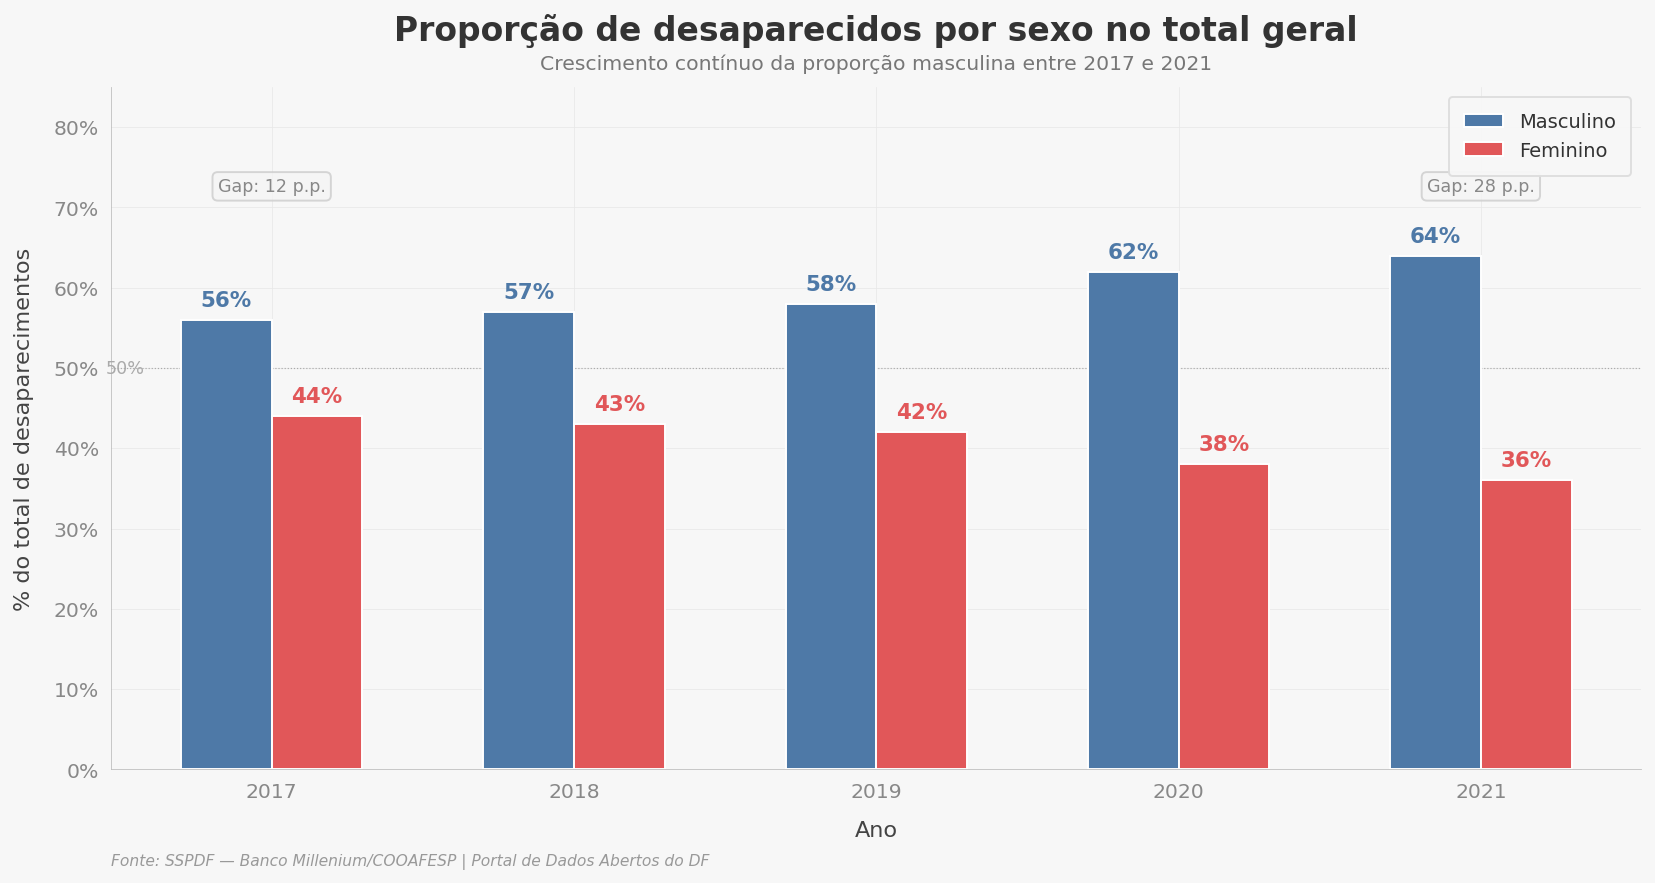

In [ ]:
# Gráfico 4 - Proporção de homens e mulheres no total geral, por ano
fig, ax = plt.subplots(figsize=(12, 6.5))

largura = 0.30
x = np.arange(len(df_totais))
anos_labels = df_totais["ano"].values
pct_m = df_totais["masculino_pct"].values
pct_f = df_totais["feminino_pct"].values

bars_m = ax.bar(x - largura/2, pct_m, width=largura, label="Masculino",
                color=PALETTE_SEXO["masc"], edgecolor="white", linewidth=1, zorder=3)
bars_f = ax.bar(x + largura/2, pct_f, width=largura, label="Feminino",
                color=PALETTE_SEXO["fem"], edgecolor="white", linewidth=1, zorder=3)

for bars, cor in [(bars_m, PALETTE_SEXO["masc"]), (bars_f, PALETTE_SEXO["fem"])]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                f"{h:.0%}", ha="center", va="bottom", fontsize=11,
                fontweight="bold", color=cor)

gap_ini = abs(pct_m[0] - pct_f[0]) * 100
gap_fim = abs(pct_m[-1] - pct_f[-1]) * 100
ax.annotate(f"Gap: {gap_ini:.0f} p.p.", xy=(x[0], 0.72), ha="center",
            fontsize=9, color="#888888",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5", edgecolor="#CCCCCC", alpha=0.8))
ax.annotate(f"Gap: {gap_fim:.0f} p.p.", xy=(x[-1], 0.72), ha="center",
            fontsize=9, color="#888888",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="#F5F5F5", edgecolor="#CCCCCC", alpha=0.8))

ax.axhline(0.5, color="#AAAAAA", linewidth=0.6, linestyle=":", zorder=1)
ax.text(-0.55, 0.5, "50%", fontsize=9, color="#AAAAAA", va="center")

ax.set_xticks(x)
ax.set_xticklabels(anos_labels)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_ylim(0, 0.85)
ax.set_title("Proporção de desaparecidos por sexo no total geral")
subtitulo(ax, "Crescimento contínuo da proporção masculina entre 2017 e 2021")
ax.set_xlabel("Ano")
ax.set_ylabel("% do total de desaparecimentos")
limpar_spines(ax)

handles = [mpatches.Patch(facecolor=PALETTE_SEXO["masc"], edgecolor="white", label="Masculino"),
           mpatches.Patch(facecolor=PALETTE_SEXO["fem"], edgecolor="white", label="Feminino")]
ax.legend(handles=handles, loc="upper right", frameon=True, fancybox=True,
          borderpad=0.8, edgecolor="#DDDDDD")

fonte_rodape(ax)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


**Interpretação:** a proporção de homens no total geral cresce de forma quase contínua: 56% (2017) → 57% (2018) → 58% (2019) → 62% (2020) → 64% (2021). A proporção de mulheres cai na mesma proporção inversa. Isso confirma a terceira pergunta secundária — houve, de fato, um crescimento real na masculinização dos casos no total geral.

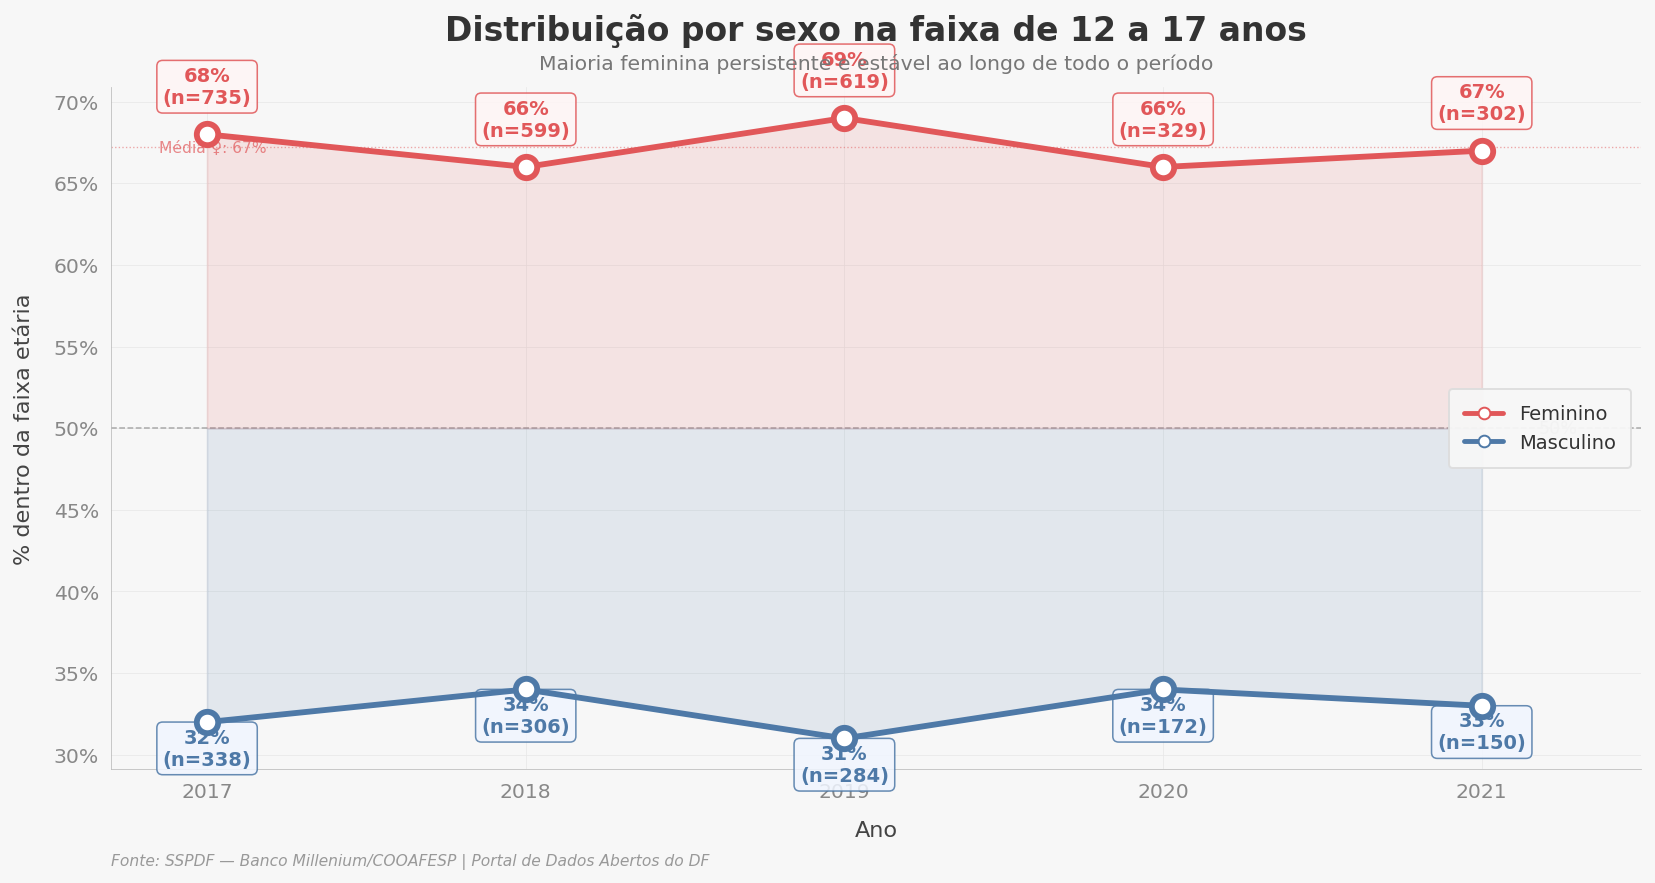

In [ ]:
# Gráfico 5 - % feminino na faixa De 12 a 17 anos ao longo do tempo (resposta à pergunta secundária 1)
faixa_1217 = df[df["faixa_etaria"] == "De 12 A 17 Anos"].sort_values("ano")

fig, ax = plt.subplots(figsize=(12, 6.5))

anos_f = faixa_1217["ano"].values
pct_fem = faixa_1217["feminino_pct"].values
pct_masc = faixa_1217["masculino_pct"].values
n_fem = faixa_1217["feminino"].values
n_masc = faixa_1217["masculino"].values

ax.fill_between(anos_f, pct_fem, 0.5, alpha=0.12, color=PALETTE_SEXO["fem"], zorder=2)
ax.fill_between(anos_f, pct_masc, 0.5, alpha=0.12, color=PALETTE_SEXO["masc"], zorder=2)

ax.plot(anos_f, pct_fem, marker="o", color=PALETTE_SEXO["fem"], linewidth=3, markersize=11,
        markerfacecolor="white", markeredgewidth=3, markeredgecolor=PALETTE_SEXO["fem"],
        label="% Feminino", zorder=5)
ax.plot(anos_f, pct_masc, marker="o", color=PALETTE_SEXO["masc"], linewidth=3, markersize=11,
        markerfacecolor="white", markeredgewidth=3, markeredgecolor=PALETTE_SEXO["masc"],
        label="% Masculino", zorder=5)

ax.axhline(0.5, linestyle="--", color="#AAAAAA", linewidth=0.8, zorder=1)
ax.text(2021.18, 0.5, "50%", va="center", fontsize=9, color="#AAAAAA")

for x_val, y_f, y_m, nf, nm in zip(anos_f, pct_fem, pct_masc, n_fem, n_masc):
    ax.annotate(f"{y_f:.0%}\n(n={int(nf)})", (x_val, y_f),
                textcoords="offset points", xytext=(0, 16), ha="center",
                fontsize=10, fontweight="bold", color=PALETTE_SEXO["fem"],
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF5F5",
                          edgecolor=PALETTE_SEXO["fem"], alpha=0.85, linewidth=0.8))
    ax.annotate(f"{y_m:.0%}\n(n={int(nm)})", (x_val, y_m),
                textcoords="offset points", xytext=(0, -22), ha="center",
                fontsize=10, fontweight="bold", color=PALETTE_SEXO["masc"],
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#F0F5FF",
                          edgecolor=PALETTE_SEXO["masc"], alpha=0.85, linewidth=0.8))

media_fem = pct_fem.mean()
ax.axhline(media_fem, linestyle=":", color=PALETTE_SEXO["fem"], linewidth=0.7, alpha=0.5)
ax.text(2016.85, media_fem, f"Média ♀: {media_fem:.0%}", fontsize=8,
        color=PALETTE_SEXO["fem"], va="center", alpha=0.7)

ax.set_title("Distribuição por sexo na faixa de 12 a 17 anos")
subtitulo(ax, "Maioria feminina persistente e estável ao longo de todo o período")
ax.set_xlabel("Ano")
ax.set_ylabel("% dentro da faixa etária")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax.set_xticks(anos_f)
ax.set_xlim(2016.7, 2021.5)
limpar_spines(ax)

handles = [Line2D([0], [0], color=PALETTE_SEXO["fem"], linewidth=2.5, marker="o",
                   markerfacecolor="white", markeredgecolor=PALETTE_SEXO["fem"], label="Feminino"),
           Line2D([0], [0], color=PALETTE_SEXO["masc"], linewidth=2.5, marker="o",
                   markerfacecolor="white", markeredgecolor=PALETTE_SEXO["masc"], label="Masculino")]
ax.legend(handles=handles, loc="center right", frameon=True, fancybox=True,
          borderpad=0.8, edgecolor="#DDDDDD")

fonte_rodape(ax)
plt.tight_layout()
plt.subplots_adjust(bottom=0.14)
plt.show()


**Interpretação:** na faixa de 12 a 17 anos, a maioria feminina é o padrão constante em todos os cinco anos (variando entre 66% e 69%), sem nenhuma inflexão relevante — é o grupo etário com a disparidade de sexo mais persistente e estável de toda a série. Essa é a resposta direta à primeira pergunta secundária: **a disparidade se mantém praticamente inalterada ao longo do período.**

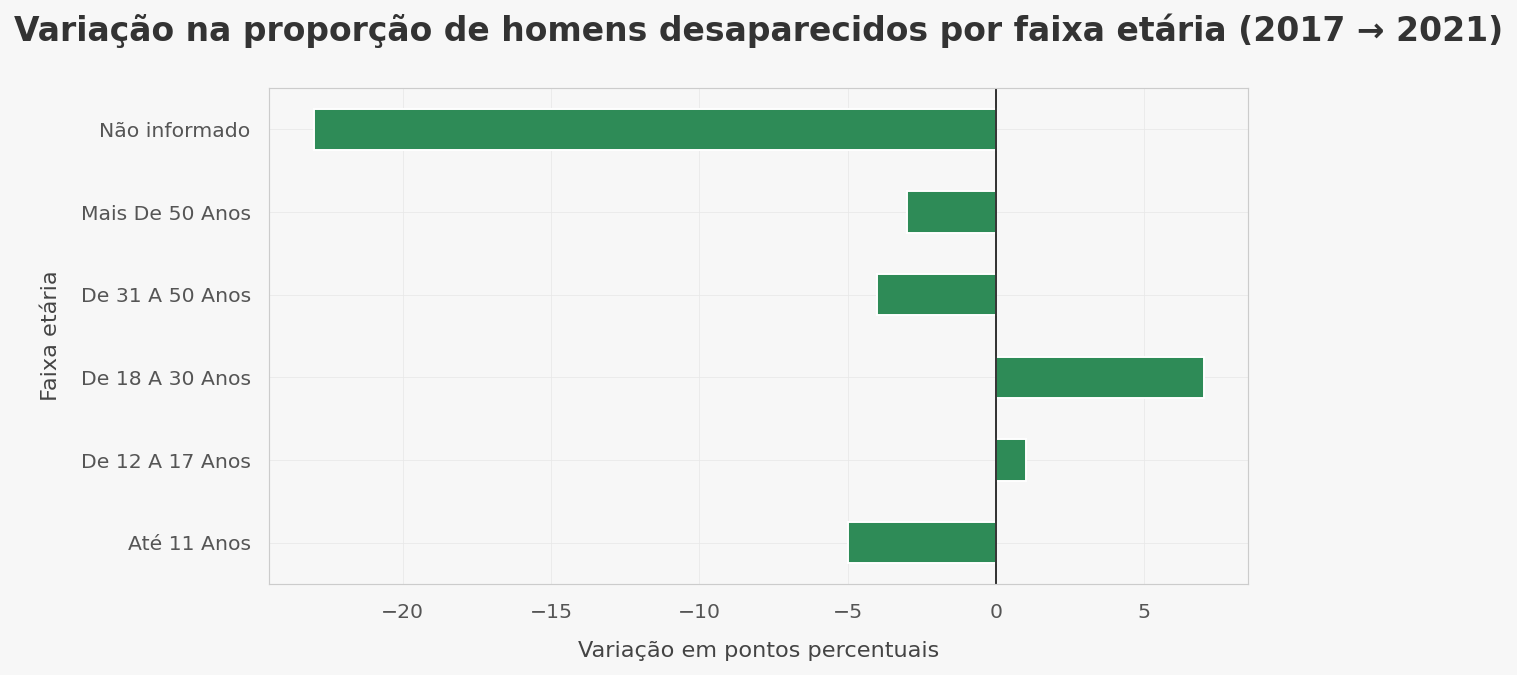

ano,2017,2021,variacao_pp
faixa_etaria,,,
Até 11 Anos,0.60,0.55,-5.0
De 12 A 17 Anos,0.32,0.33,1.0
De 18 A 30 Anos,0.66,0.73,7.0
De 31 A 50 Anos,0.78,0.74,-4.0
Mais De 50 Anos,0.74,0.71,-3.0
Não informado,0.78,0.55,-23.0


In [ ]:
# Gráfico 6 - Variação da proporção masculina por faixa etária, 2017 vs 2021 (resposta à pergunta secundária 3)
comparacao = df[df["ano"].isin([2017, 2021])].pivot(index="faixa_etaria", columns="ano", values="masculino_pct")
comparacao = comparacao.loc[[c for c in ordem_faixas if c in comparacao.index]]
comparacao["variacao_pp"] = (comparacao[2021] - comparacao[2017]) * 100

fig, ax = plt.subplots(figsize=(9, 5))
comparacao["variacao_pp"].plot(kind="barh", ax=ax, color="seagreen")
ax.set_title("Variação na proporção de homens desaparecidos por faixa etária (2017 → 2021)")
ax.set_xlabel("Variação em pontos percentuais")
ax.set_ylabel("Faixa etária")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

comparacao


**Interpretação:** o crescimento da proporção masculina não é uniforme entre as faixas. As faixas "De 18 a 30 Anos" e "De 31 a 50 Anos" — já majoritariamente masculinas — tiveram aumento expressivo na participação de homens (de 66% para 73% e de 78% para 74%, respectivamente, com leve oscilação em "De 31 a 50"). "Até 11 Anos" e "De 12 a 17 Anos" tiveram variação bem menor. Isso responde à terceira pergunta secundária: **o crescimento da proporção masculina geral é puxado, principalmente, pelas faixas adultas (18 a 50 anos), não pelas faixas infantojuvenis.**

## 6. Conclusões

1. **A queda geral de desaparecimentos (2017–2020) foi puxada quase exclusivamente pela faixa de 12 a 17 anos.** Essa faixa caiu 58% no período, enquanto faixas adultas (31–50 anos, mais de 50 anos) permaneceram estáveis ou cresceram. Os dados sugerem que o fenômeno de redução não é geral, mas concentrado em adolescentes — possivelmente relacionado à pandemia e à redução de mobilidade/fuga de casa nesse grupo, mas o conjunto de dados não permite confirmar a causa, apenas o padrão.

2. **A disparidade de sexo na faixa de 12 a 17 anos é o padrão mais persistente da série.** Em todos os cinco anos, entre 66% e 69% dos desaparecidos dessa faixa são do sexo feminino, sem nenhuma inflexão visível. Isso indica um padrão estrutural (provavelmente ligado a fuga de casa/relacionamentos, comum nessa faixa etária segundo a literatura sobre desaparecimento de adolescentes), e não um efeito pontual de algum ano específico.

3. **O aumento da proporção masculina no total geral (56% → 64%) é concentrado nas faixas adultas, não nas infantojuvenis.** As faixas de 18 a 30 e 31 a 50 anos — que já eram majoritariamente masculinas — tiveram o maior crescimento relativo na participação de homens, enquanto a faixa de 12 a 17 anos manteve sua composição majoritariamente feminina praticamente inalterada. Isso significa que **o perfil "típico" de desaparecido no DF está se deslocando**: de uma adolescente (até 2017–2018) para um homem adulto (a partir de 2020–2021), embora ambos os grupos continuem coexistindo na série.

**Limitações:** o conjunto de dados é agregado (não há registros individuais), o que impede cruzar faixa etária, sexo e desfecho do caso (encontrado, não encontrado, óbito) ou analisar por região administrativa. As conclusões aqui são sobre composição e proporção, não sobre causas dos desaparecimentos.
